In [1]:
from mymodels import *
from dataUtils import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from torch import load, no_grad, tensor
import matplotlib
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
%matplotlib inline

In [3]:
class GroupByRun:
        def __init__(self, groupby, predictor, transform=None):
            self.run = groupby[0]
            self.predictor = predictor
            df = groupby[1]
            self.paths = df['path']
            self.maps = None
            self.pAte = None
            self.ate  = df['ate'].to_numpy()
            self.are  = df['are'].to_numpy()
            self.area = df['area'].to_numpy()
            self.len = len(df)
            self.transform = transform
        
        def __getattribute__(self, name):
            if name=='maps':
                if object.__getattribute__(self,name) is None:
                    self.maps = [load_map(x) for x in self.paths.to_list()]
                    if self.transform: self.maps = [self.transform(x) for x in self.maps]
            if name=='pAte':
                if object.__getattribute__(self,name) is None:
                    self.pAte = [self.predictor(self.maps[i],self.area[i]) for i in range(self.len)]
            return object.__getattribute__(self,name)
        
        def revert(self): return np.array([revert_data_norm(ate,are) for ate,are in zip(self.ate,self.are)])

class RunDataset:
    def __init__(self, slamDataset, predictor):
        self.catalog = slamDataset.catalog
        self.transform = slamDataset.transform
        self.predictor = predictor
        self.catalog['run'] = self.catalog['path'].apply(lambda path: '/'.join(path.split('/')[:-1])).copy()
        self.groupby = list(self.catalog.groupby('run')) # [(nomeRun, dataFrameRun),...]

    def __len__(self): return len(self.groupby)

    def __getitem__(self, index): return GroupByRun(self.groupby[index],self.predictor,self.transform)

class Predictor:
    def __init__(self):
        self.model = MySqueezeNet()
        self.model.load_state_dict(
            load(f'models/squeeze_net.pth',weights_only=True))
        self.model.eval()
    
    def __call__(self, map, area):
        with no_grad():
            res = self.model(
                map.unsqueeze(0),
                tensor(area).unsqueeze(0)
            ).squeeze(0).numpy()
            return res[0]

In [7]:
for i,run in enumerate(RunDataset(make_dataset())):
    if run.run.endswith('Nw17-0'): last = run

In [67]:
M = -10000
id = 0
for run in RunDataset(make_dataset(),P).groupby:
    m = max(run[1]['ate'])
    if m>M: 
        M = m
        id = run[0]
    break

In [68]:
id

'dataset/0510025536_Layout1_PLAN4'

36-8
175


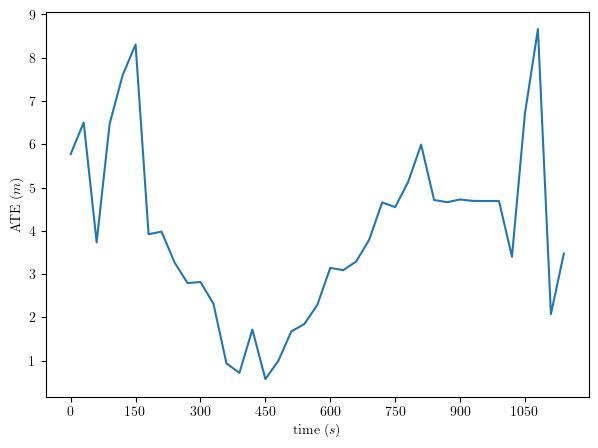

In [ ]:
P = Predictor()
rand = random.randint(0,308)
rotte = [
    'E53-0', 'E23-3', '26-0', '36-8', '0510035520_A_40_1_103','0510045922_A-40.1-030',
    'NE49-4', 'W7-3', '36-0', 'W20-0', '12-1','4-0', '2-0', '2-2', '32-G7',
    '0510045904_A_40_1_102', '56-7','16-5', '37-1'
]
i = 3
last = [run for run in RunDataset(make_dataset(),P) if rotte[i] in run.run][0]
print(rotte[i])
print(rand)

belle = [34, 29, 113, 46, 261, 196, 85]
brutte = [10, 17, 15, 28, 7, 12, 110, 256]
n = len(last.paths)


plt.subplots(figsize=(7,5))
#plt.plot(range(n), [revert_data_norm(ate,0)[0] for ate in last.pAte],label='predicted')
plt.plot(range(n), [revert_data_norm(ate,0)[0] for ate in last.ate],label='real')
plt.xticks(range(0,40,5), np.array(range(0,40,5))*30)
plt.xlabel('time ($s$)')
plt.ylabel('ATE ($m$)')
plt.savefig('high_ATE_plot.pdf',bbox_inches='tight')

In [55]:
n = len(last.paths)
row_tot = 3
rows = int(np.ceil(n/row_tot))

_,axs = plt.subplots(rows,row_tot,figsize=(15,5*rows), dpi=300)
plt.subplots_adjust(wspace=0, hspace=0)

dataset = RunDataset(make_dataset(),P)
P = Predictor()

for row in range(rows):
    for col in range(row_tot):
        idx = row*row_tot+col
        if idx==n: break
        img = last.maps[idx]
        axs[row][col].imshow(img.permute(1, 2, 0),cmap='gray')
        axs[row][col].set_axis_off()
        pAte,_ = revert_data_norm(P(img,last.area[idx]),0)
        rAte,_ = revert_data_norm(last.ate[idx],0)
        print(f'real ate: {rAte}\tpredicted ate: {pAte}')
        axs[row][col].set_title(f'{idx}        {rAte}')
plt.show()

real ate: 5.772570664534863	predicted ate: 0.19619556389564913
real ate: 6.5019102731191	predicted ate: 0.195014790296716
real ate: 3.733930217855875	predicted ate: 0.26514792126516123
real ate: 6.470902259472158	predicted ate: 0.3580097979919133
real ate: 7.593466680265345	predicted ate: 0.2366509187438175
real ate: 8.306911540716145	predicted ate: 0.24018799072664113
real ate: 3.920531475533068	predicted ate: 1.9816600949385799
real ate: 3.9800615270377366	predicted ate: 1.7233608821090955
real ate: 3.2694322288319815	predicted ate: 1.688701674525967
real ate: 2.791456450672225	predicted ate: 1.7290748912881038
real ate: 2.815740948588868	predicted ate: 1.755359558265674
real ate: 2.313074628926421	predicted ate: 1.802045328779479
real ate: 0.9359110435352103	predicted ate: 1.8246635984102981
real ate: 0.7148782204344459	predicted ate: 1.959362471286546
real ate: 1.7168107230215326	predicted ate: 1.9575984722191504
real ate: 0.571915545996728	predicted ate: 2.0848948720000147
real at